In [22]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sklearn packages
from sklearn.preprocessing import (StandardScaler, 
                                    MinMaxScaler)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.manifold import TSNE

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, train_test_split

from sklearn.metrics import (accuracy_score, 
                            classification_report, 
                            confusion_matrix, 
                            ConfusionMatrixDisplay)


# MNE Packages
import mne
from mne.datasets.sleep_physionet.age import fetch_data
mne.utils.set_config('MNE_USE_CUDA', 'true')

# Parametric T-SNE
import sys
sys.path.append("..") 
from parametric_tsne.parametric_tSNE import Parametric_tSNE


## Step 1 : Load Numpy Dataset

In [23]:
TRAIN_FILE_PATH = "../data/mne_tfr/train.npz"
VALID_FILE_PATH = "../data/mne_tfr/valid.npz"
TEST_FILE_PATH = "../data/mne_tfr/test.npz"

In [24]:
# Train
train = np.load(TRAIN_FILE_PATH)
X_train, y_train = train["arr_0"], train["arr_1"].astype(int)

# Valid
valid = np.load(VALID_FILE_PATH)
X_valid, y_valid = valid["arr_0"], valid["arr_1"].astype(int)

#X, y = np.vstack([X_train, X_valid]), np.hstack([y_train, y_valid])

# Test
test = np.load(TEST_FILE_PATH)
X_test, y_test = test["arr_0"], test["arr_1"].astype(int)

print(f"Shape of X_train : {X_train.shape} and y_train : {y_train.shape}")
print(f"Shape of X_val : {X_valid.shape} and y_valid : {y_valid.shape}")
print(f"Shape of X_test : {X_test.shape} and y_test : {y_test.shape}")

Shape of X_train : (21059, 320) and y_train : (21059,)
Shape of X_val : (3633, 320) and y_valid : (3633,)
Shape of X_test : (3693, 320) and y_test : (3693,)


In [63]:
X_train = X_train[(y_train != 0)]
X_test = X_test[(y_test != 0)]
X_valid = X_valid[(y_valid != 0)]

In [65]:
y_train = y_train[(y_train != 0)]
y_valid = y_valid[(y_valid != 0)]
y_test = y_test[(y_test != 0)]

## Step -2: Build Parametric T-SNE Model

In [68]:
class BuildParametricTsneModel:

    def __init__(self, num_outputs: int, 
                        perplexity: int, 
                        scaling:bool, 
                        input_arr : np.ndarray, 
                        epochs : int):
        """ 
            Function : Build Parametric T-SNE Model 
            Arguments:
                num_outputs : int : lower dimension 
        """
        self.num_outputs = num_outputs
        self.perplexity = perplexity
        self.scaling = scaling
        self.epochs = epochs # Number of iterations
        self.input_arr = input_arr # Higher Dimensional Array

    @staticmethod
    def MinMaxScaling(input_arr:np.ndarray):
        sc = MinMaxScaler()
        sc.fit(input_arr)

        return sc

    def train(self):
        X_copy = self.input_arr.copy() # Copy 

        # Scaling
        if self.scaling == True:
            self.sc = BuildParametricTsneModel.MinMaxScaling(input_arr = X_copy)
            X_copy = self.sc.transform(X_copy)

        # Fit the Model
        self.ptSNE = Parametric_tSNE(X_copy.shape[1], 
                                    self.num_outputs, 
                                    self.perplexity)
        self.ptSNE.fit(X_copy, epochs = self.epochs)

    def fit(self, X: np.ndarray):
        # Scaling during Transform stage
        if self.scaling == True:
            X = self.sc.transform(X)

        X = self.ptSNE.transform(X)
        return X
        

ptsne_model = BuildParametricTsneModel(
    num_outputs= 10, 
    perplexity = 30, 
    scaling = True,
    input_arr = X_train, 
    epochs= 5
)

# Fit the Model
ptsne_model.train()

/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
# Train and Test 
X_Ptrain = ptsne_model.fit(X_train)
X_Pvalid = ptsne_model.fit(X_valid)
X_Ptest = ptsne_model.fit(X_test)

341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


## Step -3 SVM Model

In [9]:
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, train_test_split
from sklearn.svm import SVC

# --- Parameter ranges (smaller but effective) --- #
C_range = np.logspace(-2, 4, 7)
gamma_range = np.logspace(-6, 1, 7)
param_grid = dict(C=C_range, gamma=gamma_range)

# --- Cross-validation setup --- #
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# --- Use a subset for faster tuning --- #
X_sub, _, y_sub, _ = train_test_split(
    X_Ptrain, y, train_size=5000, stratify=y, random_state=42
)

# --- Randomized Search with parallelization --- #
grid = RandomizedSearchCV(
    SVC(kernel='rbf'),
    param_distributions=param_grid,
    n_iter=20,            # sample only 20 parameter combinations
    cv=cv,
    n_jobs=-1,            # use all CPU cores
    random_state=42,
    verbose=1
)

# --- Fit on the subset --- #
grid.fit(X_sub, y_sub)

print("Best parameters:", grid.best_params_)
print("Best CV score: %.2f" % grid.best_score_)

# --- Retrain final model on full data --- #
best_model = SVC(kernel='rbf', **grid.best_params_)
best_model.fit(X_Ptrain, y)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'gamma': np.float64(10.0), 'C': np.float64(0.1)}
Best CV score: 0.48


SVC(C=np.float64(0.1), gamma=np.float64(10.0))

In [79]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_Ptrain, y_train)

/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [80]:
best_model = SVC()
best_model.fit(X_Ptrain, y_train)

SVC()

              precision    recall  f1-score   support

           1       0.26      0.62      0.36      2743
           2       0.00      0.00      0.00      2721
           3       0.26      0.41      0.32      2734
           4       0.00      0.00      0.00      2693

    accuracy                           0.26     10891
   macro avg       0.13      0.26      0.17     10891
weighted avg       0.13      0.26      0.17     10891



/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classificati

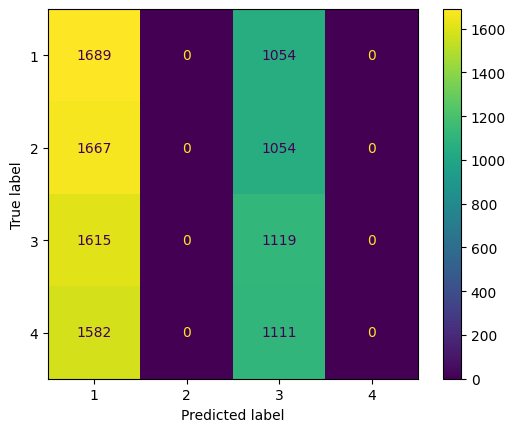

In [82]:
# Model Fitting and Predictions
y_train_pred = best_model.predict(X_Ptrain)

# Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_train, y_train_pred, ))

              precision    recall  f1-score   support

           0       0.48      1.00      0.65      1783
           1       0.00      0.00      0.00       442
           2       0.00      0.00      0.00       444
           3       0.00      0.00      0.00       515
           4       0.00      0.00      0.00       509

    accuracy                           0.48      3693
   macro avg       0.10      0.20      0.13      3693
weighted avg       0.23      0.48      0.31      3693



/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classificati

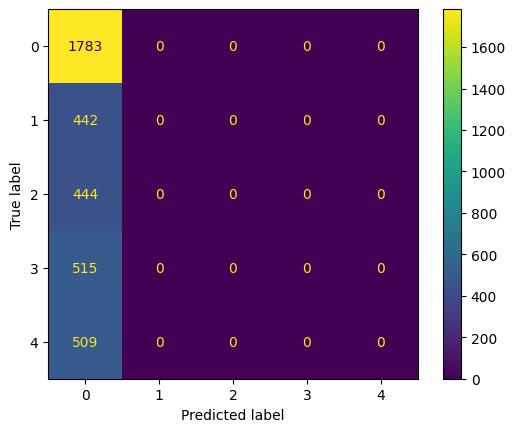

In [10]:
# Model Fitting and Predictions
y_pred = best_model.predict(X_Ptest)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_test, y_pred, ))

In [70]:
import time
import numpy as np
import torch  # for GPU detection
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

class EnsembleModelTrainer:
    """
    Trains advanced ensemble models (AdaBoost, GradientBoosting, CatBoost, LightGBM, XGBoost)
    with automatic GPU acceleration, class balancing, and execution time tracking.
    """
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.models = {}
        self.train_times = {}
        self.use_gpu = torch.cuda.is_available()

    def fit_models(self, X_train, y_train, verbose=False):
        """
        Fits ensemble models with optimized hyperparameters and returns trained models
        along with their training durations.
        """

        # --- Compute class weights ---
        classes = np.unique(y_train)
        class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
        class_weight_dict = dict(zip(classes, class_weights))
        sample_weights = np.vectorize(class_weight_dict.get)(y_train)

        print(f"\n🔍 GPU Detected: {self.use_gpu}\n")

        # Helper function for timing
        def time_fit(model_name, model, fit_fn):
            start = time.time()
            fit_fn()
            end = time.time()
            duration = round(end - start, 2)
            print(f"✅ {model_name} trained in {duration} seconds\n")
            self.train_times[model_name] = duration

        # --- 1. AdaBoost ---
        ada = AdaBoostClassifier(
            n_estimators=500,
            learning_rate=0.05,
            random_state=self.random_state
        )
        time_fit("AdaBoost", ada, lambda: ada.fit(X_train, y_train, sample_weight=sample_weights))
        self.models['AdaBoost'] = ada

        # --- 2. Gradient Boosting ---
        gb = GradientBoostingClassifier(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=6,
            min_samples_split=4,
            min_samples_leaf=2,
            subsample=0.9,
            max_features='sqrt',
            random_state=self.random_state
        )
        time_fit("GradientBoosting", gb, lambda: gb.fit(X_train, y_train, sample_weight=sample_weights))
        self.models['GradientBoosting'] = gb

        # --- 3. CatBoost ---
        cb = CatBoostClassifier(
            iterations=800,
            learning_rate=0.05,
            depth=8,
            l2_leaf_reg=5,
            border_count=128,
            random_seed=self.random_state,
            class_weights=class_weight_dict,
            task_type='GPU' if self.use_gpu else 'CPU',
            devices='0' if self.use_gpu else None,
            verbose=verbose
        )
        time_fit("CatBoost", cb, lambda: cb.fit(X_train, y_train))
        self.models['CatBoost'] = cb

        # --- 4. LightGBM ---
        lgbm_params = {
            'n_estimators': 800,
            'learning_rate': 0.05,
            'num_leaves': 64,
            'max_depth': -1,
            'min_child_samples': 20,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'reg_alpha': 0.2,
            'reg_lambda': 0.2,
            'class_weight': 'balanced',
            'random_state': self.random_state,
        }
        if self.use_gpu:
            lgbm_params.update({'device_type': 'gpu'})
        lgbm = LGBMClassifier(**lgbm_params)
        time_fit("LightGBM", lgbm, lambda: lgbm.fit(X_train, y_train))
        self.models['LightGBM'] = lgbm

        # --- 5. XGBoost ---
        xgb_params = {
            'n_estimators': 800,
            'learning_rate': 0.05,
            'max_depth': 8,
            'min_child_weight': 3,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'gamma': 0.3,
            'reg_alpha': 0.2,
            'reg_lambda': 0.2,
            'random_state': self.random_state,
            'use_label_encoder': False,
            'eval_metric': 'mlogloss'
        }
        if self.use_gpu:
            xgb_params.update({'tree_method': 'gpu_hist', 'predictor': 'gpu_predictor'})
        xgb = XGBClassifier(**xgb_params)
        time_fit("XGBoost", xgb, lambda: xgb.fit(X_train, y_train, sample_weight=sample_weights))
        self.models['XGBoost'] = xgb

        # --- Summary of execution times ---
        print("⏱️ Training Summary:")
        for name, t in self.train_times.items():
            print(f"   • {name}: {t} seconds")

        return self.models


In [71]:
trainer = EnsembleModelTrainer(random_state=42)
trained_models = trainer.fit_models(X_Ptrain, y_train, verbose=True)


🔍 GPU Detected: False

✅ AdaBoost trained in 5.65 seconds

✅ GradientBoosting trained in 36.91 seconds

0:	learn: 1.3861580	total: 8.75ms	remaining: 6.99s
1:	learn: 1.3860250	total: 11.2ms	remaining: 4.48s
2:	learn: 1.3858891	total: 14.7ms	remaining: 3.91s
3:	learn: 1.3857749	total: 18ms	remaining: 3.59s
4:	learn: 1.3856623	total: 21.4ms	remaining: 3.4s
5:	learn: 1.3855515	total: 24.8ms	remaining: 3.28s
6:	learn: 1.3854591	total: 28.8ms	remaining: 3.26s
7:	learn: 1.3853392	total: 32.6ms	remaining: 3.23s
8:	learn: 1.3852305	total: 36.2ms	remaining: 3.18s
9:	learn: 1.3850995	total: 40.1ms	remaining: 3.17s
10:	learn: 1.3850351	total: 43.6ms	remaining: 3.13s
11:	learn: 1.3849396	total: 47.6ms	remaining: 3.12s
12:	learn: 1.3848229	total: 51.1ms	remaining: 3.1s
13:	learn: 1.3847272	total: 55ms	remaining: 3.09s
14:	learn: 1.3846469	total: 58.6ms	remaining: 3.07s
15:	learn: 1.3845822	total: 61.8ms	remaining: 3.03s
16:	learn: 1.3845294	total: 62.9ms	remaining: 2.9s
17:	learn: 1.3844238	total: 

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3], got [1 2 3 4]

In [ ]:
ada_model = trained_models['AdaBoost']
lgbm_model = trained_models['LightGBM']
xgb_model = trained_models["XGBoost"]
lightgbm_model = trained_models["LightGBM"]

/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.27      0.01      0.01      2743
           2       0.00      0.00      0.00      2721
           3       0.25      0.60      0.35      2734
           4       0.00      0.00      0.00      2693

    accuracy                           0.15     10891
   macro avg       0.10      0.12      0.07     10891
weighted avg       0.13      0.15      0.09     10891



/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:15

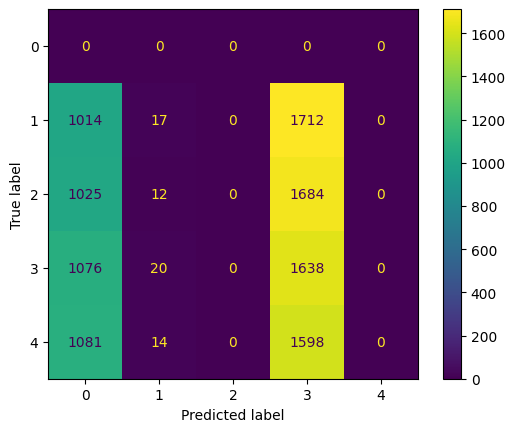

In [72]:
# Model Fitting and Predictions
y_train_pred = lgbm_model.predict(X_Ptrain)

# Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lgbm_model.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_train, y_train_pred, ))

ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (5).

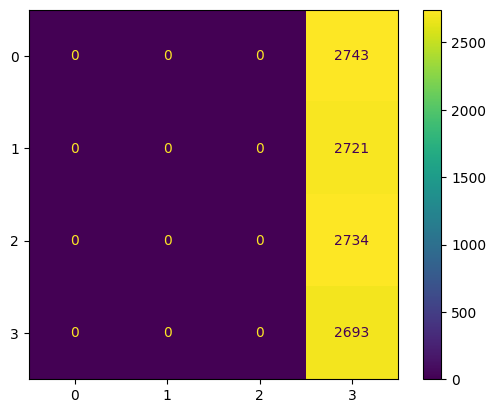

In [73]:
# Model Fitting and Predictions
y_train_pred = ada_model.predict(X_Ptrain)

# Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ada_model.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_train, y_train_pred, ))

ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (5).

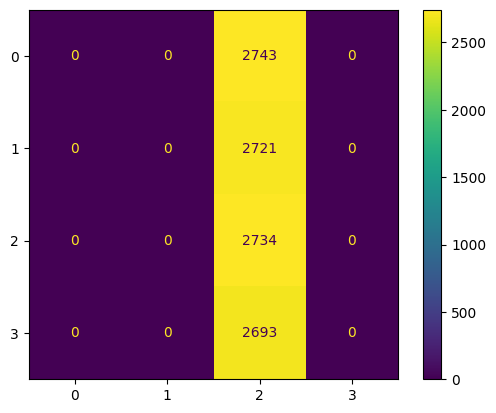

In [74]:
# Model Fitting and Predictions
y_train_pred = xgb_model.predict(X_Ptrain)

# Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_train, y_train_pred, ))

/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.27      0.01      0.01      2743
           2       0.00      0.00      0.00      2721
           3       0.25      0.60      0.35      2734
           4       0.00      0.00      0.00      2693

    accuracy                           0.15     10891
   macro avg       0.10      0.12      0.07     10891
weighted avg       0.13      0.15      0.09     10891



/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:15

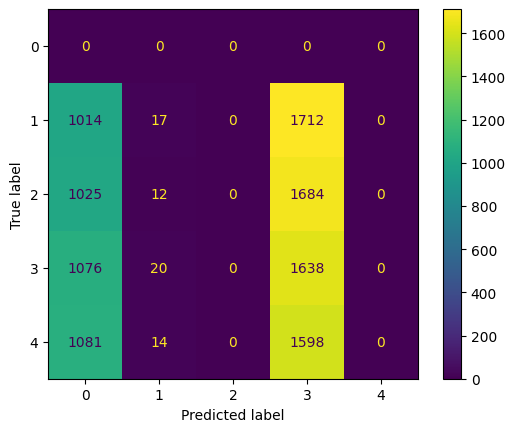

In [75]:
# Model Fitting and Predictions
y_train_pred = lightgbm_model.predict(X_Ptrain)

# Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lightgbm_model.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_train, y_train_pred, ))

In [87]:
gbc = GradientBoostingClassifier(n_estimators= 1000, random_state = 42)
gbc.fit(X_Ptrain, y_train)

GradientBoostingClassifier(n_estimators=1000, random_state=42)

              precision    recall  f1-score   support

           1       0.76      0.75      0.75      2743
           2       0.77      0.75      0.76      2721
           3       0.77      0.76      0.76      2734
           4       0.73      0.76      0.75      2693

    accuracy                           0.76     10891
   macro avg       0.76      0.76      0.76     10891
weighted avg       0.76      0.76      0.76     10891



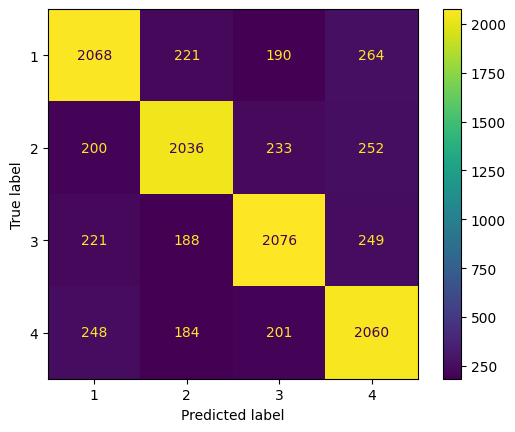

In [88]:
# Model Fitting and Predictions
y_train_pred = gbc.predict(X_Ptrain)

# Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gbc.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_train, y_train_pred, ))

              precision    recall  f1-score   support

           1       0.51      0.54      0.53       442
           2       0.52      0.52      0.52       444
           3       0.60      0.57      0.59       515
           4       0.59      0.59      0.59       509

    accuracy                           0.56      1910
   macro avg       0.56      0.56      0.56      1910
weighted avg       0.56      0.56      0.56      1910



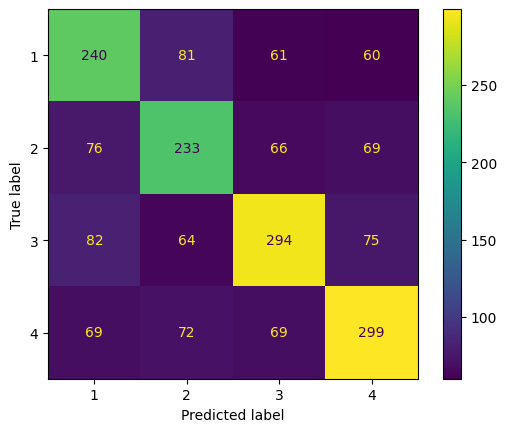

In [89]:
# Model Fitting and Predictions
y_test_pred = gbc.predict(X_Ptest)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gbc.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_test, y_test_pred))

# --- Random Forest Classifier

In [76]:
rf = RandomForestClassifier()
rf.fit(X_Ptrain, y_train)

RandomForestClassifier()

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2743
           2       1.00      1.00      1.00      2721
           3       1.00      1.00      1.00      2734
           4       1.00      1.00      1.00      2693

    accuracy                           1.00     10891
   macro avg       1.00      1.00      1.00     10891
weighted avg       1.00      1.00      1.00     10891



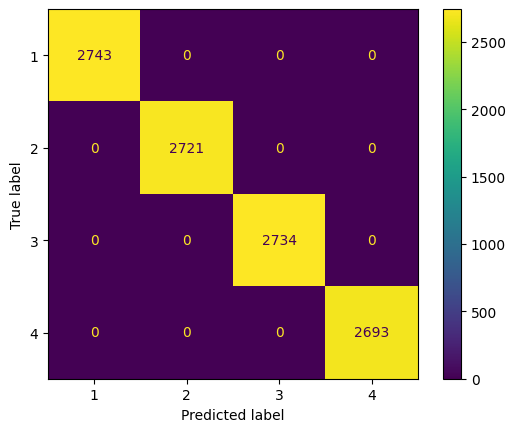

In [77]:
# Model Fitting and Predictions
y_train_pred = rf.predict(X_Ptrain)

# Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_train, y_train_pred, ))

              precision    recall  f1-score   support

           1       0.64      0.67      0.65       442
           2       0.64      0.64      0.64       444
           3       0.72      0.69      0.71       515
           4       0.73      0.72      0.72       509

    accuracy                           0.68      1910
   macro avg       0.68      0.68      0.68      1910
weighted avg       0.68      0.68      0.68      1910



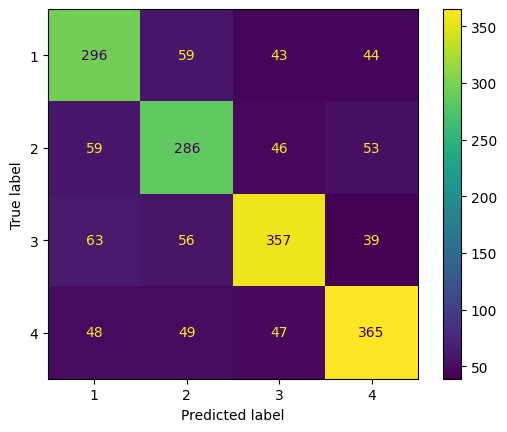

In [78]:
# Model Fitting and Predictions
y_test_pred = rf.predict(X_Ptest)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_test, y_test_pred))

In [56]:
from sklearn.linear_model import LogisticRegression

In [66]:
lr = LogisticRegression(multi_class = "auto", class_weight= "balanced")
lr.fit(X_train, y_train)

/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', multi_class='auto')

              precision    recall  f1-score   support

           1       0.25      1.00      0.40      2743
           2       0.00      0.00      0.00      2721
           3       0.00      0.00      0.00      2734
           4       0.00      0.00      0.00      2693

    accuracy                           0.25     10891
   macro avg       0.06      0.25      0.10     10891
weighted avg       0.06      0.25      0.10     10891



/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/sklearn/metrics/_classificati

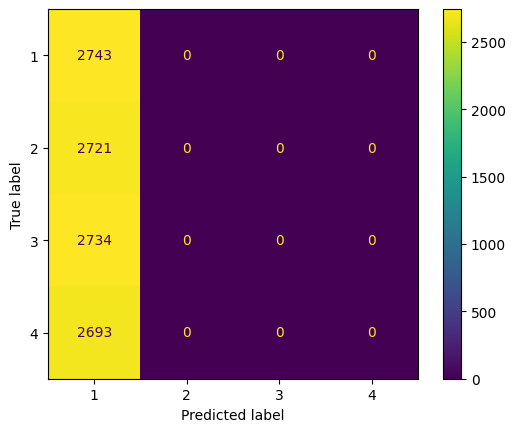

In [67]:
# Model Fitting and Predictions
y_train_pred = lr.predict(X_train)

# Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_train, y_train_pred, ))